# 🌊 Canal Abierto — Análisis Hidráulico con Python
## Módulo: Funciones y Estructuras de Control

**Curso:** Fundamentos de Programación
**Universidad:** Universidad de Sucre
**Año:** 2026

**Integrantes:**
- zarate caro, carlos
- De La Ossa Castilla, José David
- Cárdenas Álvarez, Luis
- Noriega Peralta, Luz Dayana
- Triana Palencia, María
- Armesto Bolaño, Maicol
- Clemente De La Cruz, Said
- Alber Francisco Montiel Ramos
---

## Contexto del Proyecto

Se requiere un programa en Python que calcule el caudal $Q$ que puede transportar un canal abierto. El usuario puede elegir entre sección **rectangular** o **trapezoidal**. El programa evalúa el caudal para diferentes profundidades del agua mediante un ciclo repetitivo.

## Marco Teórico

### Ecuación de Manning

$$Q = \frac{1}{n} \cdot A \cdot R_h^{2/3} \cdot S^{1/2}$$

Donde:
- $Q$: Caudal (m³/s)
- $n$: Coeficiente de rugosidad de Manning (adimensional)
- $A$: Área de la sección transversal (m²)
- $S$: Pendiente longitudinal (m/m)
- $R_h = A/P$: Radio hidráulico (m)

### Geometría del canal rectangular
$$A = b \cdot y \qquad P = b + 2y$$

### Geometría del canal trapezoidal
$$A = (b + z \cdot y) \cdot y \qquad P = b + 2y\sqrt{1+z^2}$$


In [1]:
# Celda 1 — Importación de librerías
import math
import matplotlib.pyplot as plt
import seaborn as sns

print("="*55)
print("  ANÁLISIS HIDRÁULICO DE CANAL ABIERTO")
print("="*55)


  ANÁLISIS HIDRÁULICO DE CANAL ABIERTO


In [2]:
# Celda 2 — Función: calcular_geometria
def calcular_geometria(tipo_canal, b, y, z=0):
    """
    Calcula el área y el perímetro mojado de un canal abierto.

    Parámetros:
    -----------
    tipo_canal : str
        Tipo de sección: 'rectangular' o 'trapezoidal'.
    b : float
        Ancho de la base (m).
    y : float
        Tirante o profundidad del agua (m).
    z : float, opcional
        Relación de talud lateral (adimensional). Por defecto 0.

    Retorna:
    --------
    tuple
        (area, perimetro) en m² y m respectivamente.
    """
    if tipo_canal == 'rectangular':
        area = b * y
        perimetro = b + 2 * y
    elif tipo_canal == 'trapezoidal':
        area = (b + z * y) * y
        perimetro = b + 2 * y * math.sqrt(1 + z**2)
    else:
        raise ValueError("tipo_canal debe ser 'rectangular' o 'trapezoidal'")
    return area, perimetro

# Prueba rápida
print("Prueba rectangular (b=2, y=1):", calcular_geometria('rectangular', 2, 1))
print("Prueba trapezoidal (b=2, y=1, z=1.5):", calcular_geometria('trapezoidal', 2, 1, 1.5))


Prueba rectangular (b=2, y=1): (2, 4)
Prueba trapezoidal (b=2, y=1, z=1.5): (3.5, 5.60555127546399)


In [3]:
# Celda 3 — Función: calcular_caudal
def calcular_caudal(A, P, n, S):
    """
    Calcula el caudal usando la ecuación de Manning.

    Parámetros:
    -----------
    A : float
        Área de la sección transversal (m²).
    P : float
        Perímetro mojado (m).
    n : float
        Coeficiente de rugosidad de Manning.
    S : float
        Pendiente longitudinal (m/m).

    Retorna:
    --------
    float
        Caudal Q (m³/s).
    """
    Rh = A / P
    Q = (1 / n) * A * (Rh ** (2/3)) * (S ** 0.5)
    return Q

# Prueba rápida
A_test, P_test = calcular_geometria('rectangular', 2, 1)
print("Prueba caudal rectangular (b=2, y=1, n=0.015, S=0.001):",
      round(calcular_caudal(A_test, P_test, 0.015, 0.001), 3))


Prueba caudal rectangular (b=2, y=1, n=0.015, S=0.001): 2.656


In [4]:
# Celda 4 — Simulación con ciclo repetitivo y tabla de resultados

# Parámetros fijos
b = 2.0      # ancho de base (m)
n = 0.015    # rugosidad Manning (concreto)
S = 0.001    # pendiente (m/m)
z = 1.5      # talud trapezoidal
tirantes = [0.5, 1.0, 1.5, 2.0]

# Listas para almacenar resultados (para graficar después)
caudales_rect = []
caudales_trap = []

print(f"{'y (m)':>7} {'Q Rectangular (m³/s)':>22} {'Q Trapezoidal (m³/s)':>22}")
print("-" * 55)

for y in tirantes:
    # Rectangular
    A_r, P_r = calcular_geometria('rectangular', b, y)
    Q_r = calcular_caudal(A_r, P_r, n, S)
    caudales_rect.append(round(Q_r, 3))

    # Trapezoidal
    A_t, P_t = calcular_geometria('trapezoidal', b, y, z)
    Q_t = calcular_caudal(A_t, P_t, n, S)
    caudales_trap.append(round(Q_t, 3))

    print(f"{y:>7.1f} {Q_r:>22.3f} {Q_t:>22.3f}")


  y (m)   Q Rectangular (m³/s)   Q Trapezoidal (m³/s)
-------------------------------------------------------
    0.5                  1.014                  1.471
    1.0                  2.656                  5.390
    1.5                  4.499                 12.159
    2.0                  6.435                 22.269


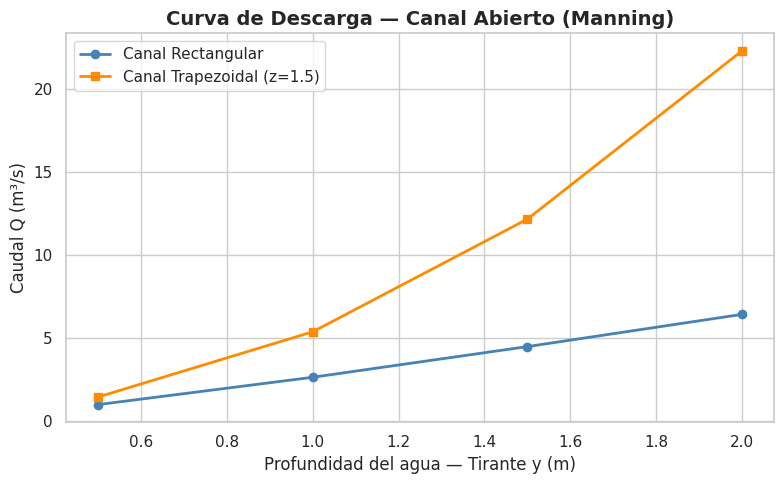


Observación: El canal trapezoidal transporta mayor caudal a iguales profundidades
porque su sección crece lateralmente por el talud, reduciendo la fricción relativa.


In [5]:
# Celda 5 — Visualización: Curva de Descarga
sns.set_theme(style='whitegrid')

plt.figure(figsize=(8, 5))
plt.plot(tirantes, caudales_rect, marker='o', color='steelblue',
         linewidth=2, label='Canal Rectangular')
plt.plot(tirantes, caudales_trap, marker='s', color='darkorange',
         linewidth=2, label='Canal Trapezoidal (z=1.5)')

plt.title('Curva de Descarga — Canal Abierto (Manning)', fontsize=14, fontweight='bold')
plt.xlabel('Profundidad del agua — Tirante y (m)', fontsize=12)
plt.ylabel('Caudal Q (m³/s)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nObservación: El canal trapezoidal transporta mayor caudal a iguales profundidades")
print("porque su sección crece lateralmente por el talud, reduciendo la fricción relativa.")


## 🧠 Reflexión Final

1. **¿Por qué separar `calcular_geometria` y `calcular_caudal` en funciones distintas?**  
   Porque cada función tiene una responsabilidad única (modularidad). Si mañana se agrega un canal circular, solo se modifica `calcular_geometria` sin tocar la ecuación de Manning.

2. **¿Por qué el canal trapezoidal transporta más caudal que el rectangular a igual profundidad?**  
   Porque su área crece más rápido que su perímetro mojado al aumentar `y`, lo que mejora el radio hidráulico y por tanto la velocidad del flujo.

3. **¿Por qué se usaron listas y `.append()` en lugar de solo `print()`?**  
   Porque `print()` no guarda los datos. Las listas permiten almacenarlos para graficarlos y reutilizarlos en otros cálculos.
